In [ ]:
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

In [ ]:
import os

DATASET_PATH = r"D:\Development\8th Sem Project\TomatoClassification\dataset\color"
OUTPUT_PATH  = r"D:\Development\8th Sem Project\TomatoClassification\dataset\processed"

IMAGE_SIZE = (224, 224)

TOMATO_CLASSES = [
    "Tomato__Bacterial_spot",
    "Tomato__Early_blight",
    "Tomato__Late_blight",
    "Tomato__Leaf_Mold",
    "Tomato__Septoria_leaf_spot",
    "Tomato__Spider_mites Two-spotted_spider_mite",
    "Tomato__Target_Spot",
    "Tomato__Tomato_Yellow_Leaf_Curl_Virus",
    "Tomato__Tomato_mosaic_virus",
    "Tomato__healthy"
]

# Verify path exists
print(f"Path exists: {os.path.exists(DATASET_PATH)}")
print(f"Folders found: {os.listdir(DATASET_PATH)}")
print(f"✅ {len(TOMATO_CLASSES)} tomato classes defined")

In [ ]:
import os

DATASET_PATH = r"D:\Development\8th Sem Project\TomatoClassification\dataset\color"

print("📂 Exact folder names inside your color folder:\n")
for folder in sorted(os.listdir(DATASET_PATH)):
    print(f'"{folder}"')

In [24]:
print("📊 Dataset Summary\n" + "="*40)

class_counts = {}

# Auto-detect all Tomato folders directly from disk
TOMATO_CLASSES = [
    f for f in os.listdir(DATASET_PATH) 
    if f.startswith("Tomato") and os.path.isdir(os.path.join(DATASET_PATH, f))
]

for cls in sorted(TOMATO_CLASSES):
    cls_path = os.path.join(DATASET_PATH, cls)
    images = [f for f in os.listdir(cls_path)
              if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    class_counts[cls] = len(images)
    print(f"✅ {cls:<55} → {len(images)} images")

print("="*40)
print(f"📁 Total Classes  : {len(class_counts)}")
print(f"🖼️  Total Images   : {sum(class_counts.values())}")

if class_counts:
    max_count = max(class_counts.values())
    min_count = min(class_counts.values())
    print(f"\n⚖️  Max class: {max_count} images")
    print(f"⚖️  Min class: {min_count} images")
    if max_count / min_count > 2:
        print("⚠️  WARNING: Dataset is imbalanced!")
    else:
        print("✅ Dataset is reasonably balanced")

📊 Dataset Summary
✅ Tomato___Bacterial_spot                                 → 2127 images
✅ Tomato___Early_blight                                   → 1000 images
✅ Tomato___Late_blight                                    → 1909 images
✅ Tomato___Leaf_Mold                                      → 952 images
✅ Tomato___Septoria_leaf_spot                             → 1771 images
✅ Tomato___Spider_mites Two-spotted_spider_mite           → 1676 images
✅ Tomato___Target_Spot                                    → 1404 images
✅ Tomato___Tomato_Yellow_Leaf_Curl_Virus                  → 5357 images
✅ Tomato___Tomato_mosaic_virus                            → 373 images
✅ Tomato___healthy                                        → 1591 images
📁 Total Classes  : 10
🖼️  Total Images   : 18160

⚖️  Max class: 5357 images
⚖️  Min class: 373 images
⚠️  WARNING: Dataset is imbalanced!


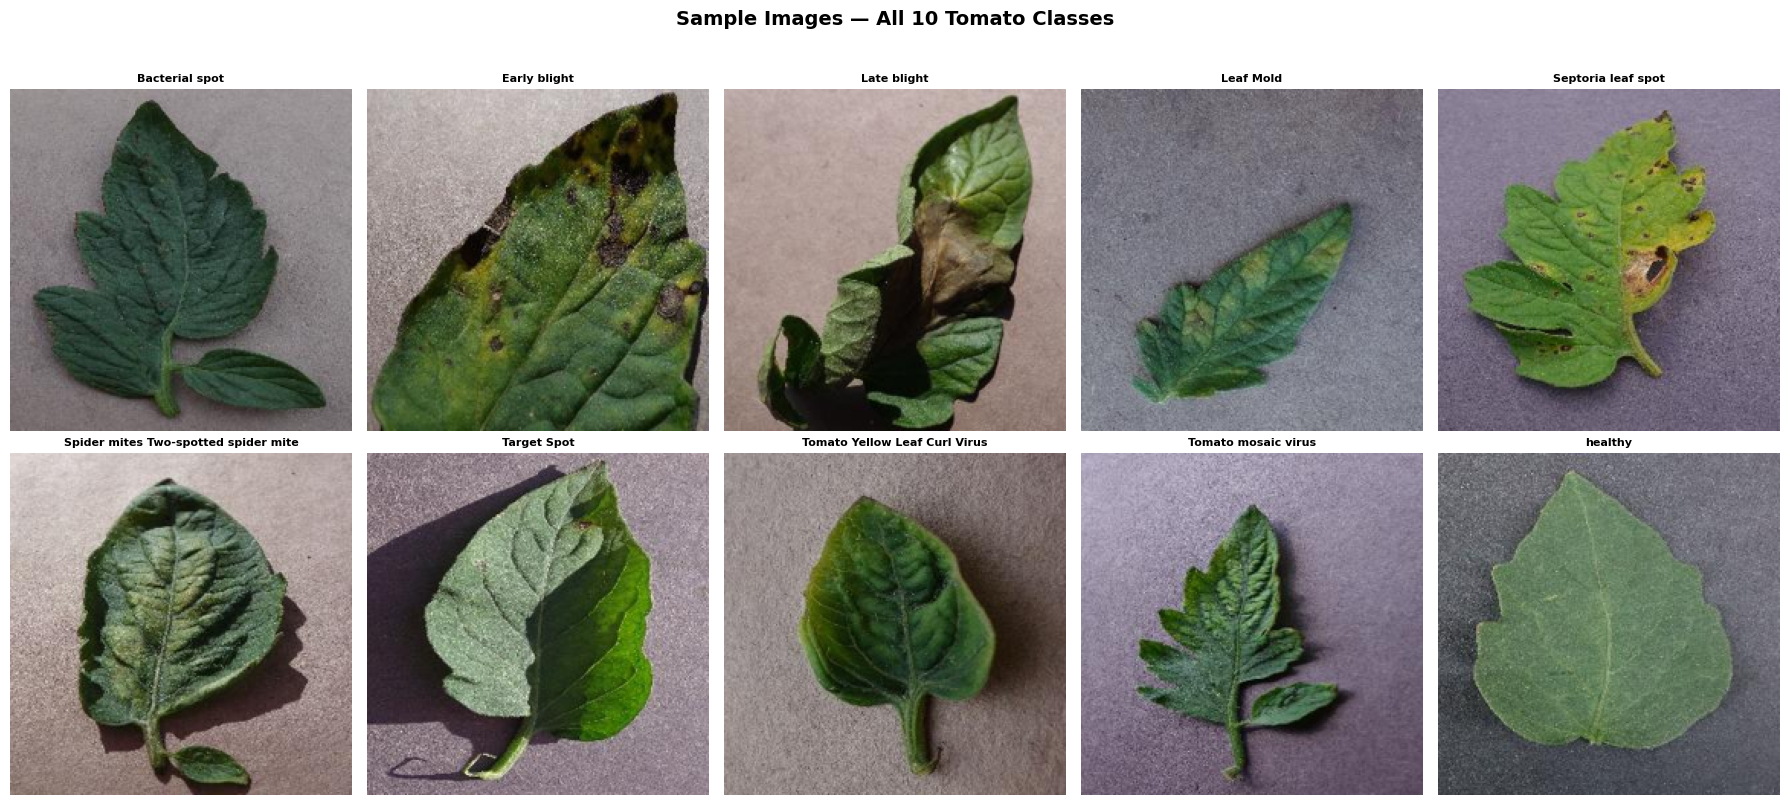

✅ Sample images saved to outputs folder!


In [22]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for idx, cls in enumerate(sorted(TOMATO_CLASSES)):
    cls_path = os.path.join(DATASET_PATH, cls)
    images = os.listdir(cls_path)
    
    sample_img_path = os.path.join(cls_path, images[0])
    img = Image.open(sample_img_path).convert("RGB")
    img_resized = img.resize(IMAGE_SIZE)
    
    axes[idx].imshow(img_resized)
    axes[idx].set_title(
        cls.replace("Tomato___", "").replace("_", " "),
        fontsize=8, fontweight='bold'
    )
    axes[idx].axis('off')

plt.suptitle("Sample Images — All 10 Tomato Classes",
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
os.makedirs("../outputs", exist_ok=True)
plt.savefig("../outputs/sample_images.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Sample images saved to outputs folder!")

In [23]:
from sklearn.model_selection import train_test_split
print("🔄 Resizing & Splitting Dataset...\n")

# Max images per class to fix imbalance
MAX_IMAGES_PER_CLASS = 1000

split_counts = {'train': {}, 'val': {}, 'test': {}}

for cls in sorted(TOMATO_CLASSES):
    cls_path = os.path.join(DATASET_PATH, cls)
    
    all_images = [f for f in os.listdir(cls_path)
                  if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
    
    # Cap at MAX_IMAGES_PER_CLASS to balance dataset
    if len(all_images) > MAX_IMAGES_PER_CLASS:
        import random
        random.seed(42)
        all_images = random.sample(all_images, MAX_IMAGES_PER_CLASS)
    
    # Split 70% train, 15% val, 15% test
    train_imgs, temp_imgs = train_test_split(all_images, test_size=0.30, random_state=42)
    val_imgs,   test_imgs = train_test_split(temp_imgs,  test_size=0.50, random_state=42)
    
    split_data = {'train': train_imgs, 'val': val_imgs, 'test': test_imgs}
    
    for split, img_list in split_data.items():
        dest_dir = os.path.join(OUTPUT_PATH, split, cls)
        os.makedirs(dest_dir, exist_ok=True)
        split_counts[split][cls] = len(img_list)
        
        for img_name in img_list:
            src = os.path.join(cls_path, img_name)
            dst = os.path.join(dest_dir, img_name)
            img = Image.open(src).convert("RGB")
            img = img.resize(IMAGE_SIZE, Image.LANCZOS)
            img.save(dst)

print(f"{'Class':<45} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 72)
for cls in sorted(TOMATO_CLASSES):
    name = cls.replace("Tomato___", "")
    t  = split_counts['train'].get(cls, 0)
    v  = split_counts['val'].get(cls, 0)
    te = split_counts['test'].get(cls, 0)
    print(f"{name:<45} {t:>8} {v:>8} {te:>8}")

print("-" * 72)
print(f"{'TOTAL':<45} "
      f"{sum(split_counts['train'].values()):>8} "
      f"{sum(split_counts['val'].values()):>8} "
      f"{sum(split_counts['test'].values()):>8}")
print("\n✅ Splitting complete!")

🔄 Resizing & Splitting Dataset...

Class                                            Train      Val     Test
------------------------------------------------------------------------
Bacterial_spot                                     700      150      150
Early_blight                                       700      150      150
Late_blight                                        700      150      150
Leaf_Mold                                          666      143      143
Septoria_leaf_spot                                 700      150      150
Spider_mites Two-spotted_spider_mite               700      150      150
Target_Spot                                        700      150      150
Tomato_Yellow_Leaf_Curl_Virus                      700      150      150
Tomato_mosaic_virus                                261       56       56
healthy                                            700      150      150
------------------------------------------------------------------------
TOTAL           

In [25]:
print("📁 Processed Dataset Structure:\n")

total_all = 0
for split in ['train', 'val', 'test']:
    split_path = os.path.join(OUTPUT_PATH, split)
    total = 0
    for cls in os.listdir(split_path):
        cls_dir = os.path.join(split_path, cls)
        count = len(os.listdir(cls_dir))
        total += count
    total_all += total
    print(f"  {split.upper():<8} → {total} images")

print(f"\n  {'TOTAL':<8} → {total_all} images")
print(f"\n✅ Preprocessing complete!")
print(f"📂 Saved to: {OUTPUT_PATH}")

📁 Processed Dataset Structure:

  TRAIN    → 6527 images
  VAL      → 1399 images
  TEST     → 1399 images

  TOTAL    → 9325 images

✅ Preprocessing complete!
📂 Saved to: D:\Development\8th Sem Project\TomatoClassification\dataset\processed
